<a href="https://colab.research.google.com/github/ashutoshnaikwadi/Sentiment-Analysis-on-Flipkart-Reviews/blob/main/sentiment%20analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
reviews = pd.read_csv('/content/flipkart_reviews.csv')

In [ ]:
reviews.head()

,Product_name,Review,Rating
0,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Best under 60k Great performanceI got it for a...,5
1,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Good perfomence...,5
2,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Great performance but usually it has also that...,5
3,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,My wife is so happy and best product 👌🏻😘,5
4,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,"Light weight laptop with new amazing features,...",5


In [ ]:
reviews.shape

(2304, 3)

In [ ]:
reviews.duplicated().sum()

np.int64(123)

In [ ]:
reviews = reviews.drop_duplicates(ignore_index=True)

In [ ]:
reviews.isnull().sum()

,0
Product_name,0
Review,0
Rating,0


In [ ]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2181 entries, 0 to 2180
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Product_name  2181 non-null   object
 1   Review        2181 non-null   object
 2   Rating        2181 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 51.2+ KB


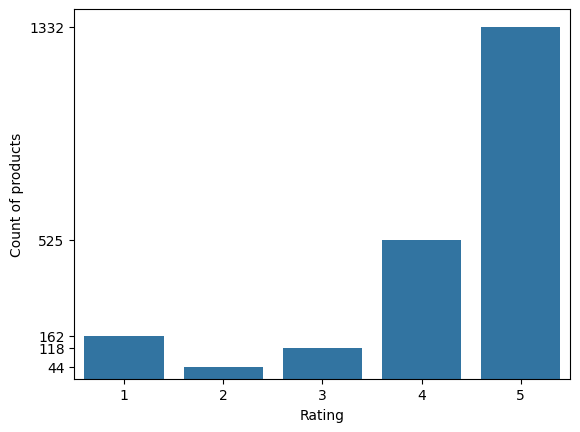

In [ ]:
fg1 = sns.countplot(data=reviews, x='Rating')
fg1.set_yticks(reviews.groupby('Rating')['Product_name'].count())
fg1.set_ylabel('Count of products')
plt.show()

In [ ]:
pip install contractions

In [ ]:
import nltk
import re
import string
import contractions

In [ ]:
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [ ]:
def clean_text(text):
  text = contractions.fix(text)
  text = text.lower()
  text = re.sub(r'http\S+|www\S+|https\S+', '', text)
  text = re.sub(r'[^a-zA-Z0-9\s]','', text)
  text = re.sub(r'\s+', ' ', text).strip()
  pos_tag = nltk.pos_tag(word_tokenize(text))
  return pos_tag

In [ ]:
reviews['Review'] = reviews['Review'].apply(clean_text)

In [ ]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'):
      return wordnet.ADJ #'a'
    elif tag.startswith('V'):
      return wordnet.VERB #'v'
    elif tag.startswith('N'):
      return wordnet.NOUN #'n'
    elif tag.startswith('R'):
      return wordnet.ADV #'r'
    else:
      return wordnet.NOUN #'n'

def lemmatize(tokens):
    lemmas = []
    for word, tag in tokens:
        wordnet_tag = get_wordnet_pos(tag)
        lemmas.append(lemmatizer.lemmatize(word, pos=wordnet_tag))
    return lemmas

In [ ]:
reviews['Review'] = reviews['Review'].apply(lemmatize)

In [ ]:
reviews['Review'] = reviews['Review'].apply(lambda x : ' '.join(x))

In [ ]:
reviews['Review']

,Review
0,best under 60k great performancei get it for a...
1,good perfomence
2,great performance but usually it have also tha...
3,my wife be so happy and best product
4,light weight laptop with new amaze feature bat...
...,...
2176,great display accurate colour at this price range
2177,superb monitor first bring 1 use for 2 month a...
2178,awesome
2179,only one issue with adapter


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(reviews['Review'])
Y = reviews['Rating']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, Y_train)

RandomForestClassifier()

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print('Accuracy:', accuracy_score(y_pred, Y_test), '\n')
print('Classification report:\n', classification_report(y_pred, Y_test))

Accuracy: 0.8260869565217391 

Classification report:
               precision    recall  f1-score   support

           1       0.87      0.96      0.91        27
           2       0.70      1.00      0.82         7
           3       0.57      1.00      0.72        13
           4       0.48      0.98      0.65        55
           5       1.00      0.78      0.87       335

    accuracy                           0.83       437
   macro avg       0.72      0.94      0.80       437
weighted avg       0.91      0.83      0.84       437



In [ ]:
cm = confusion_matrix(y_pred, Y_test)

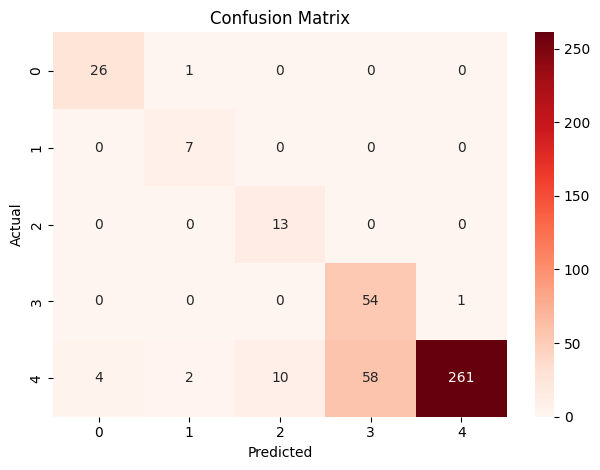

In [ ]:
fg2 = sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
fg2.set_xlabel('Predicted')
fg2.set_ylabel('Actual')
fg2.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()